 **The goal is to extract watersheds in Mt. Elgon and perform some example analyses using the elevation data in the watershed**

 Source code: https://pythongis.org/part3/chapter-12/nb/00-watershed-analysis-with-pysheds.html

Watershed analysis is the process of analyzing the landscape and hydrology of watersheds – land areas where surface water drains to a common outlet, such as a river, lake, or ocean. In this case study we are interested in understanding how various factors, such as the area and/or topographic relief, vary within a set of river watersheds in the Mt. Elgon region to be able to explore relationships related to landscape uplift and erosion. Thus, we will calculate a series of values for each watershed and then investigate how they vary within the study area.

**Steps:**
1.   Loading the digital elevation data for the study region
2.   Defining the areas of the watersheds of interest
3.   Analyzing the landscapes in each watershed
4.   Visualizing the results

In [50]:
# Install libraries

!pip install pysheds
!pip install rioxarray

In [51]:
# Import libraries needed for analysis

import geopandas as gpd
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from pysheds.grid import Grid
from pysheds.view import Raster, ViewFinder
import rioxarray as rxr
import xarray as xr

In [52]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
# Set plotting style for the visualizations

plt.style.use("bmh")

**Loading the digital elevation data**

In [54]:
# Load the digital elevation data

# S3 bucket containing the data

bucket_dem_fp = "/content/drive/MyDrive/GitHub_Desktop/Data/pysheds_mt_elgon/mt_elgon_DEM1.tif"

# Read the input data file
south_island = rxr.open_rasterio(bucket_dem_fp).drop_vars("band")[0]

In [55]:
# Examine the data

south_island

<xarray.DataArray (y: 3081, x: 2705)> Size: 33MB
[8334105 values with dtype=float32]
Coordinates:
  * y            (y) float64 25kB 1.602 1.602 1.602 ... 0.7471 0.7468 0.7465
  * x            (x) float64 22kB 34.08 34.08 34.08 34.08 ... 34.83 34.83 34.83
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

**Extracting watersheds using pysheds**

In [56]:
# Extracting watersheds using pysheds

data = south_island.data
affine = south_island.rio.transform()
crs = south_island.rio.crs
# Keep same data type as DEM values for nodata
nodata = data.dtype.type(-9999)

In [57]:
# Activate ViewFinder and read the elevation data

viewfinder = ViewFinder(affine=affine, shape=data.shape, crs=crs, nodata=nodata)
dem = Raster(data, viewfinder=viewfinder)

In [58]:
# Create pysheds Grid object, which allows visualization of the DEM data and the use of various Grid methods for processing the data

grid = Grid.from_raster(dem)

In [59]:
# Preparing a DEM for analysis in pysheds

checkpoint = True
if checkpoint:
    # Create checkpoint_data directory if it does not exist
    wd = Path.cwd()
    newdir = wd / "checkpoint_data"
    newdir.mkdir(parents=True, exist_ok=True)

In [60]:
# Detect number of pits in DEM

pits = grid.detect_pits(dem)
npits = np.count_nonzero(pits)

# Check number of pits
print(f"Number of pits found: {npits}")

Number of pits found: 31532


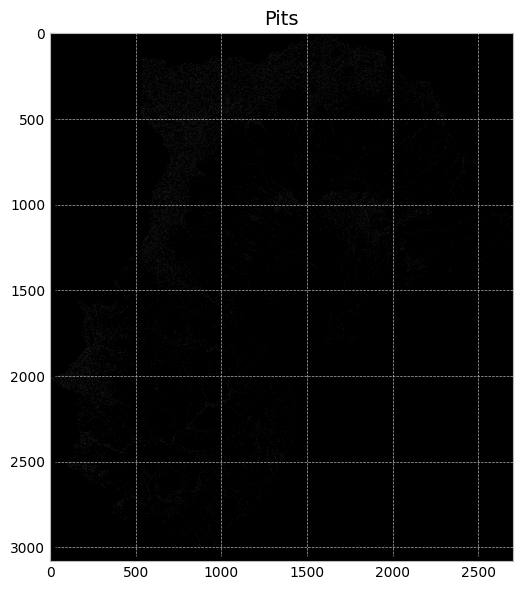

In [61]:
# Visualize pit locations

if npits > 0:
    # Plot pits
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_alpha(0)

    plt.imshow(pits, cmap="Greys_r", zorder=1)
    plt.title("Pits", size=14)
    plt.tight_layout()

In [62]:
# Fill pits and check they have been filled

pit_filled_dem = grid.fill_pits(dem)
pits = grid.detect_pits(pit_filled_dem)
assert not pits.any()

In [63]:
# Detect additional depressions

depressions = grid.detect_depressions(pit_filled_dem)

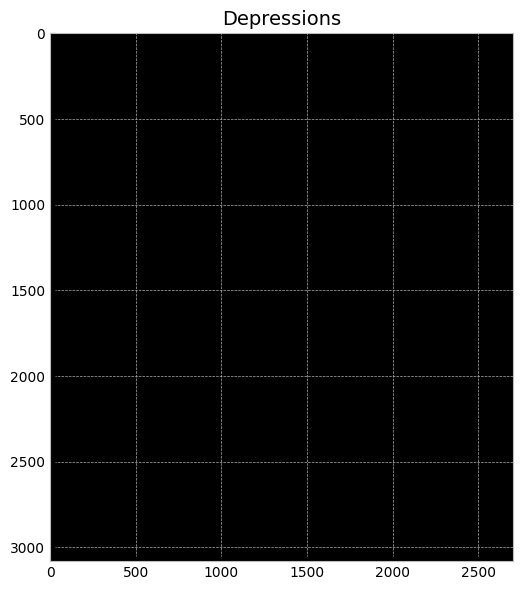

In [64]:
#  Visualize the locations of depressions in the DEM as we did for the pits

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

plt.imshow(depressions, cmap="Greys_r", zorder=1)
plt.title("Depressions", size=14)
plt.tight_layout()

In [65]:
# Writing output to file (in case of notebook restart)

if checkpoint:
    # Write dataset to file
    grid.to_raster(
        pit_filled_dem,
        "checkpoint_data/pit_filled_dem.tif",
        blockxsize=16,
        blockysize=16,
    )
    # NOTE: Need to use "int" for dtype to avoid write error for boolean values
    grid.to_raster(
        depressions,
        "checkpoint_data/detected_depressions.tif",
        dtype=int,
        blockxsize=16,
        blockysize=16,
    )

In [66]:
# Read in the output datat

continue_from_here = False
if continue_from_here:
    grid, pit_filled_dem = continue_pysheds("checkpoint_data/pit_filled_dem.tif")
    _, depressions = continue_pysheds("checkpoint_data/detected_depressions.tif")

In [67]:
# Continue preparing the DEM for analysis in pysheds

# Fill depressions
flooded_dem = grid.fill_depressions(pit_filled_dem)
depressions = grid.detect_depressions(flooded_dem)
assert not depressions.any()

In [68]:
# Write flooded_dem to file using the same approach as above for the pit-filled DEM

if checkpoint:
    # Write dataset to file
    grid.to_raster(
        flooded_dem, "checkpoint_data/flooded_dem.tif", blockxsize=16, blockysize=16
    )

In [69]:
continue_from_here = False
if continue_from_here:
    grid, pit_filled_dem = continue_pysheds("checkpoint_data/pit_filled_dem.tif")
    _, depressions = continue_pysheds("checkpoint_data/detected_depressions.tif")
    _, flooded_dem = continue_pysheds("checkpoint_data/flooded_dem.tif")

In [70]:
# Depressions filled. Proceed to handling flow routing across flats (such as lakes) in the DEM

# Detect flats
flats = grid.detect_flats(flooded_dem)
nflats = np.count_nonzero(flats)

# Check number of flats
print(f"Number of flats found: {nflats}")

Number of flats found: 4406612


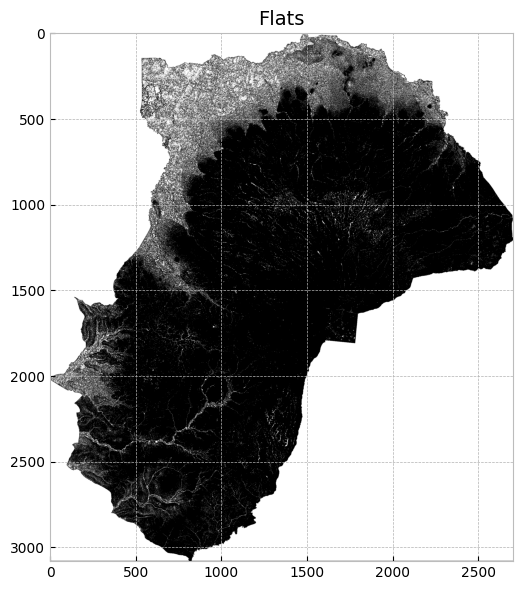

In [71]:
# Visualize the locations of flats regions in the DEM

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

plt.imshow(flats, cmap="Greys_r", zorder=1)
plt.title("Flats", size=14)
plt.tight_layout()

In [72]:
# Process flat regions in the flooded DEM to determine how water would be routed

# Resolve flats
inflated_dem = grid.resolve_flats(flooded_dem)

**Calculating values related to surface water flows**

**Definition:** Flow accumulation is a calculation of how many upstream cells drain into each cell in the DEM

It is raster-based GIS analysis tool that calculates the total upslope area (or cumulative weight) draining into each cell. It identifies areas of concentrated flow to map stream networks (high accumulation) and topographical ridges (zero accumulation)

At this stage we aim to do the following:
1.   Direction water flows at all points on the surface of the DEM (flow direction)
2.   Number of cells draining into each cell in the DEM (flow accumulation)



In [73]:
# Compute flow direction based on corrected DEM (D8)
fdir = grid.flowdir(inflated_dem)

# Compute flow accumulation based on computed flow direction
acc = grid.accumulation(fdir)

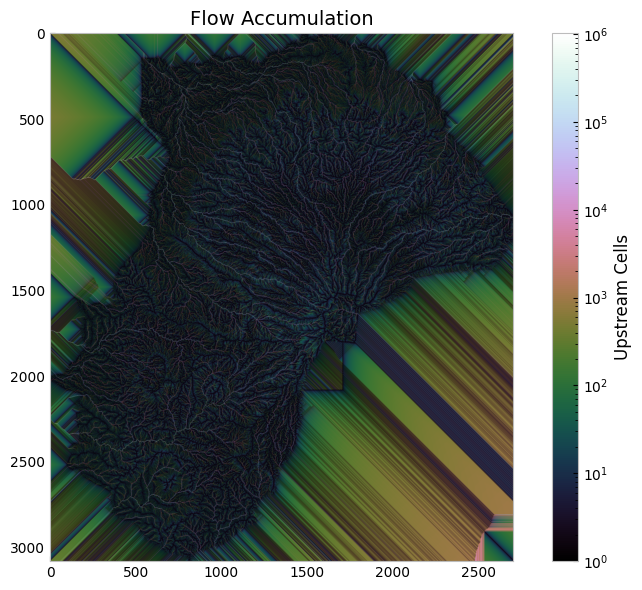

In [74]:
# Plot values for the flow directions and flow accumulation

# Plot flow accumulation, if requested
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
im = ax.imshow(
    acc,
    zorder=2,
    cmap="cubehelix",
    norm=colors.LogNorm(1, acc.max()),
    interpolation="bilinear",
)
plt.colorbar(im, ax=ax, label="Upstream Cells")
plt.title("Flow Accumulation", size=14)
plt.tight_layout()


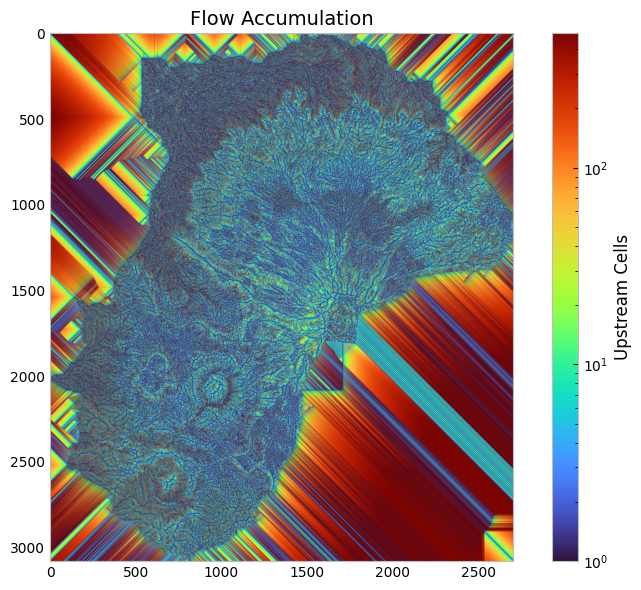

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

vmax = np.percentile(acc[acc > 0], 90)  # clip top 10% of outliers

im = ax.imshow(
    acc,
    zorder=2,
    cmap="turbo",
    norm=colors.LogNorm(vmin=1, vmax=vmax),
    interpolation="bilinear",
)
plt.colorbar(im, ax=ax, label="Upstream Cells")
plt.title("Flow Accumulation", size=14)
plt.tight_layout()

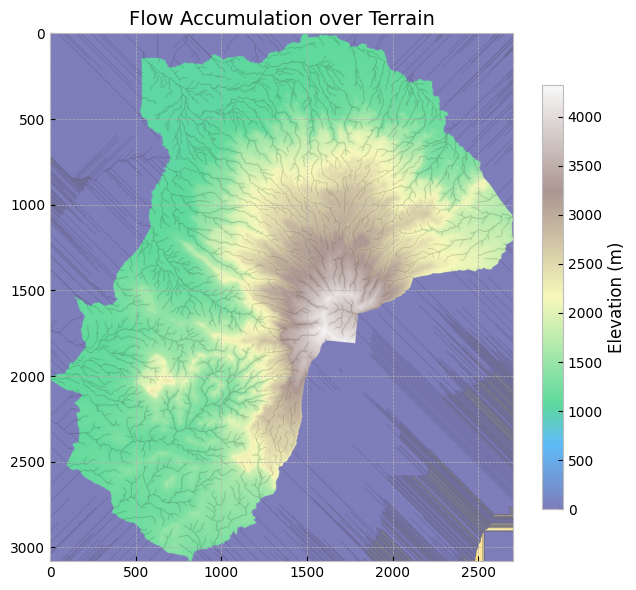

In [76]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot terrain as background
terrain_im = ax.imshow(dem, cmap="terrain", alpha=0.6)
cbar_dem = plt.colorbar(terrain_im, ax=ax, fraction=0.03, pad=0.04)
cbar_dem.set_label("Elevation (m)")

# Overlay flow accumulation
acc_masked = np.where(acc > 1000, acc, np.nan)
im = ax.imshow(
    acc_masked,
    cmap="YlOrRd",
    norm=colors.LogNorm(vmin=1000, vmax=acc.max()),
    interpolation="bilinear",
)

plt.title("Flow Accumulation over Terrain", size=14)
plt.tight_layout()

In [77]:
if checkpoint:
    # Write flow accumulation and directions to file
    grid.to_raster(
        acc, "checkpoint_data/flow_accumulation.tif", blockxsize=16, blockysize=16
    )
    grid.to_raster(
        fdir, "checkpoint_data/flow_directions.tif", blockxsize=16, blockysize=16
    )

In [78]:
continue_from_here = False
if continue_from_here:
    grid, pit_filled_dem = continue_pysheds("checkpoint_data/pit_filled_dem.tif")
    _, depressions = continue_pysheds("checkpoint_data/detected_depressions.tif")
    _, flooded_dem = continue_pysheds("checkpoint_data/flooded_dem.tif")
    _, acc = continue_pysheds("checkpoint_data/flow_accumulation.tif")
    _, fdir = continue_pysheds("checkpoint_data/flow_directions.tif")

**Defining and extracting a watershed**

In [79]:
# We need to select a river outlet and specify its location (single point where all water from a catchment drains out)

outlet = (33.920, 0.942) # Near Butaleja/Manafwa border

In [80]:
# Snap outlet point to nearby cell with high flow accumulation
x_snap, y_snap = grid.snap_to_mask(acc > 10000, outlet)

# Delineate the watershed
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, xytype="coordinate")

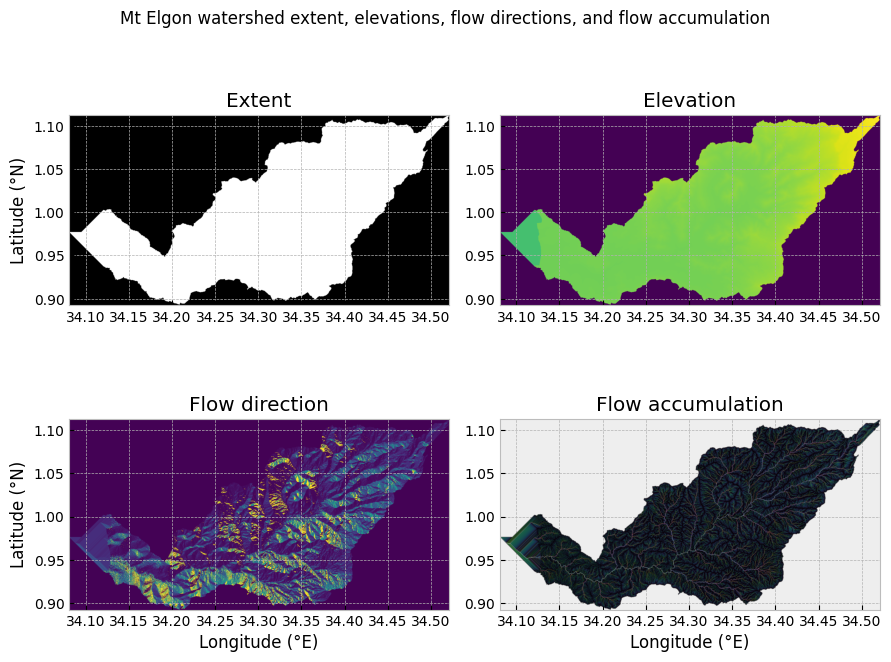

In [81]:
# Visualize and inspect the results

# Clip and set view extents
grid.clip_to(catch)
catch_view = grid.view(catch).astype(float)
fdir_view = grid.view(fdir).astype(float)
acc_view = grid.view(acc).astype(float)
dem_view = grid.view(dem).astype(float)

# Create figure and plot axes
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
fig.patch.set_alpha(0)

# Plot watershed extent
im = axes[0, 0].imshow(catch_view, extent=grid.extent, zorder=1, cmap="Greys_r")
axes[0, 0].set_title("Extent")
axes[0, 0].set_ylabel("Latitude (°N)")

# Plot watershed elevations
im = axes[0, 1].imshow(dem_view, extent=grid.extent, zorder=1, cmap="viridis")
axes[0, 1].set_title("Elevation")

# Plot watershed flow directions
im = axes[1, 0].imshow(fdir_view, extent=grid.extent, zorder=1, cmap="viridis")
axes[1, 0].set_title("Flow direction")
axes[1, 0].set_xlabel("Longitude (°E)")
axes[1, 0].set_ylabel("Latitude (°N)")

# Plot watershed flow accumulation
im = axes[1, 1].imshow(
    acc_view,
    extent=grid.extent,
    zorder=2,
    cmap="cubehelix",
    norm=colors.LogNorm(1, acc.max()),
    interpolation="bilinear",
)
axes[1, 1].set_title("Flow accumulation")
axes[1, 1].set_xlabel("Longitude (°E)")

# Add a figure title
plt.suptitle("Mt Elgon watershed extent, elevations, flow directions, and flow accumulation")
plt.tight_layout()



**Analyzing the watershed data**

In [82]:
# Calculating the distance from each point in the watershed to the defined outlet point

dist = grid.distance_to_outlet(
    x=x_snap,
    y=y_snap,
    fdir=fdir,
    xytype="coordinate",
)

Text(0.5, 1.0, 'Distance to outlet')

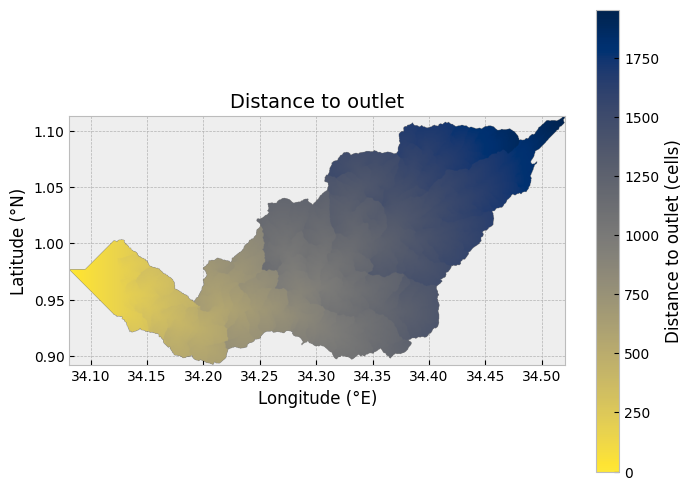

In [83]:
# Plot the distance to the outlet

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)

# Plot distance to outlet
im = ax.imshow(dist, extent=grid.extent, zorder=2, cmap="cividis_r")

# Add colorbar, axis labels, and a title
plt.colorbar(im, ax=ax, label="Distance to outlet (cells)")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Distance to outlet", size=14)

In [84]:
# Extract the network of channels in the watershed

branches = grid.extract_river_network(fdir, acc > 500)

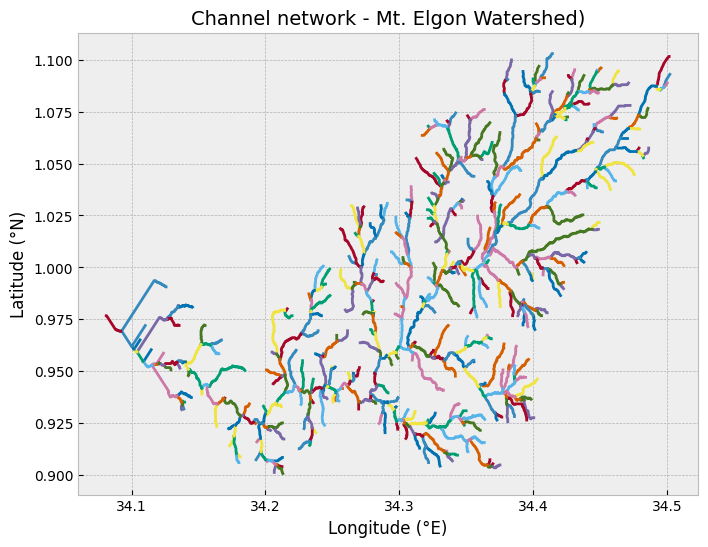

In [87]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot channel segments
for branch in branches["features"]:
    line = np.asarray(branch["geometry"]["coordinates"])
    plt.plot(line[:, 0], line[:, 1])

# Add axis labels and title
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Channel network - Mt. Elgon Watershed)", size=14);

Text(0.5, 1.0, 'Channel network - Mt. Elgon Watershed')

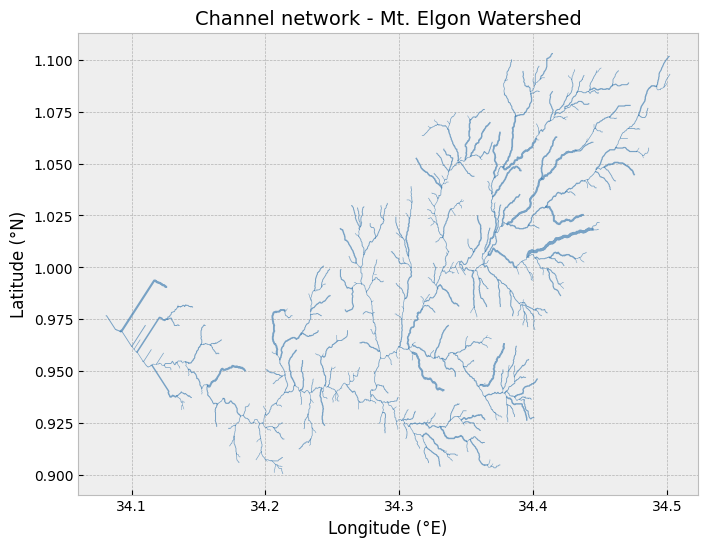

In [85]:
# Visualize network of channels

fig, ax = plt.subplots(figsize=(8, 6))

for branch in branches["features"]:
    line = np.asarray(branch["geometry"]["coordinates"])
    n_coords = len(line)  # longer segments = more upstream cells = main channels
    plt.plot(line[:, 0], line[:, 1],
             color="steelblue",
             linewidth=0.3 + (n_coords / 100),  # thicker for longer segments
             alpha=0.7)

plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.title("Channel network - Mt. Elgon Watershed", size=14)

**Exporting the watershed data to xarray**